# F1 Feature Engineering

This notebook demonstrates feature engineering for F1 lap time prediction and tyre degradation modeling.

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_race_data
from src.feature_engineering import add_driver_normalization, preprocess_laps

# Load data for Monza
df = load_race_data(2023, 'Monza')
print(f"Loaded {len(df)} lap records")

# Apply feature engineering
df = add_driver_normalization(df)
print("Applied driver normalization")

# Show the new columns
print(df[['Driver', 'LapTimeSeconds', 'NormalizedLapTime']].head())

core           INFO 	Loading data for Italian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WAR

Loaded 948 lap records
Applied driver normalization
  Driver  LapTimeSeconds  NormalizedLapTime
0    VER          87.905           1.215922
1    VER          86.163          -0.526078
2    VER          85.702          -0.987078
3    VER          86.050          -0.639078
4    VER          86.176          -0.513078


Features shape: (948, 4)
Target shape: (948,)
Features: ['LapNumber', 'TyreLife', 'Stint', 'CompoundEncoded']


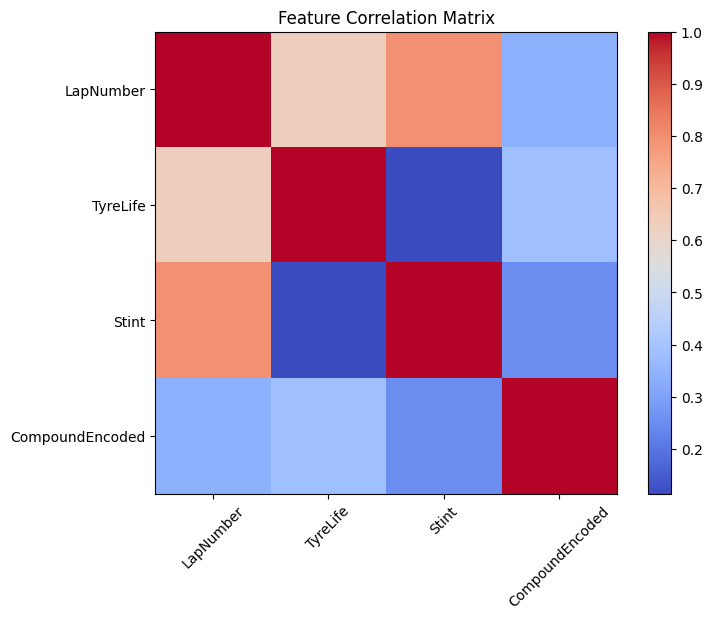

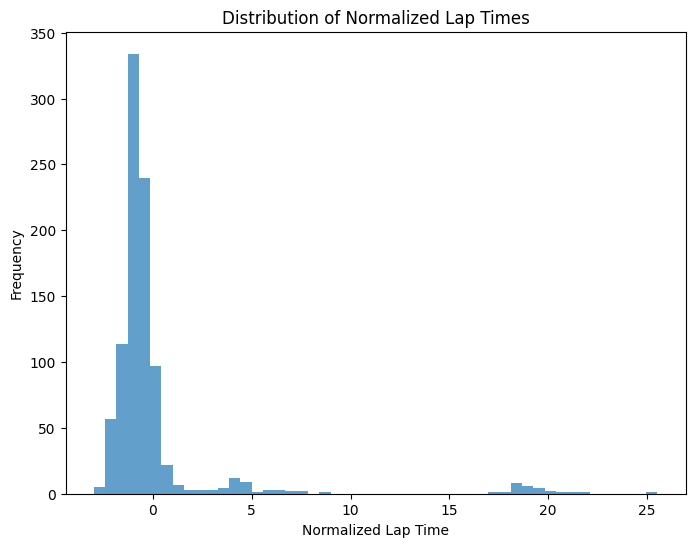

In [2]:
# Preprocess for modeling
features, target = preprocess_laps(df)
print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")
print("Features:", features.columns.tolist())

# Visualize feature correlations
plt.figure(figsize=(8, 6))
corr = features.corr()
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.show()

# Distribution of target
plt.figure(figsize=(8, 6))
plt.hist(target, bins=50, alpha=0.7)
plt.xlabel('Normalized Lap Time')
plt.ylabel('Frequency')
plt.title('Distribution of Normalized Lap Times')
plt.show()